<a href="https://colab.research.google.com/github/AryaPutra-182/Klasifikasi-Citra-Buah-Pisang-Menggunakan-Metode-KNN/blob/main/2318034MukhammadAryaPutraKlasifikasiCitraPisangMetodeKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. MOUNT DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2. IMPORT LIBRARY**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from skimage.feature import graycomatrix, graycoprops

# **3.PATH DATASET**

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset buah"

categories = ["Fresh Banana", "Rotten Banana"]

# **4. MENGECEK FOLDER**

In [ ]:
for category in categories:
    print(category, "->", os.path.exists(os.path.join(DATASET_PATH, category)))

Fresh Banana -> True
Rotten Banana -> True


# **5.LOAD DATA**

In [ ]:
data = []
labels = []
file_names = []

for label, category in enumerate(categories):
    folder = os.path.join(DATASET_PATH, category)

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        data.append(img)
        labels.append(label)
        file_names.append(file)

data = np.array(data)
labels = np.array(labels)

print("Total data:", len(data))

Total data: 1906


# **6.VISUALISASI DISTRIBUSI DATA**

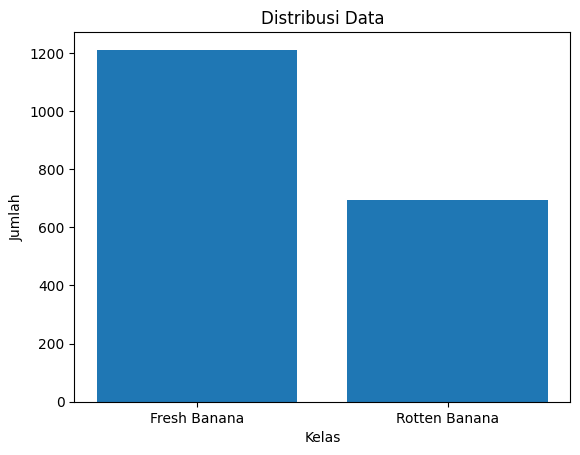

In [ ]:
unique, counts = np.unique(labels, return_counts=True)

plt.figure()
plt.bar(categories, counts)
plt.title("Distribusi Data")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

# **7.EKSTRAKSI FITUR WARNA DAN TEKSTUR**

In [ ]:
def extract_features(image):
    # WARNA (HSV)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    color = [
        np.mean(hsv[:,:,0]),
        np.mean(hsv[:,:,1]),
        np.mean(hsv[:,:,2])
    ]

    # TEKSTUR (GLCM)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)

    texture = [
        graycoprops(glcm, 'contrast')[0][0],
        graycoprops(glcm, 'homogeneity')[0][0],
        graycoprops(glcm, 'energy')[0][0],
        graycoprops(glcm, 'correlation')[0][0]
    ]

    return np.hstack([color, texture])

# **8.MENYIMPAN HASIL EKSTRAKSI FITUR**

In [ ]:
feature_list = []

for i in range(len(data)):
    feat = extract_features(data[i])

    feature_list.append({
        "Image": file_names[i],
        "H_mean": feat[0],
        "S_mean": feat[1],
        "V_mean": feat[2],
        "Contrast": feat[3],
        "Homogeneity": feat[4],
        "Energy": feat[5],
        "Correlation": feat[6]
    })

df_features = pd.DataFrame(feature_list)

output_path = "/content/fitur_pisang.xlsx"
df_features.to_excel(output_path, index=False)

print("File fitur berhasil disimpan:", output_path)

File fitur berhasil disimpan: /content/fitur_pisang.xlsx


In [ ]:
from google.colab import files
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **9.PROSES FITUR**

In [ ]:
features = np.array([extract_features(img) for img in data])
print("Shape fitur:", features.shape)

Shape fitur: (1906, 7)


# **10. SPLIT DATA**

In [ ]:
X_train, X_test, y_train, y_test, file_train, file_test = train_test_split(
    features, labels, file_names, test_size=0.2, random_state=42
)

# **11. TRAINING KNN**

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# **12. PREDIKSI DAN AKURASI**

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9319371727748691


# **13. CONFUSION MATRIX**

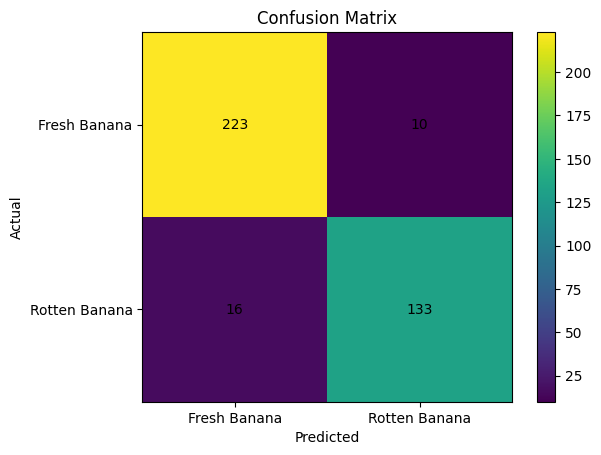

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(2), categories)
plt.yticks(range(2), categories)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

# **14. VISUALISASI HASIL PREDIKSI**

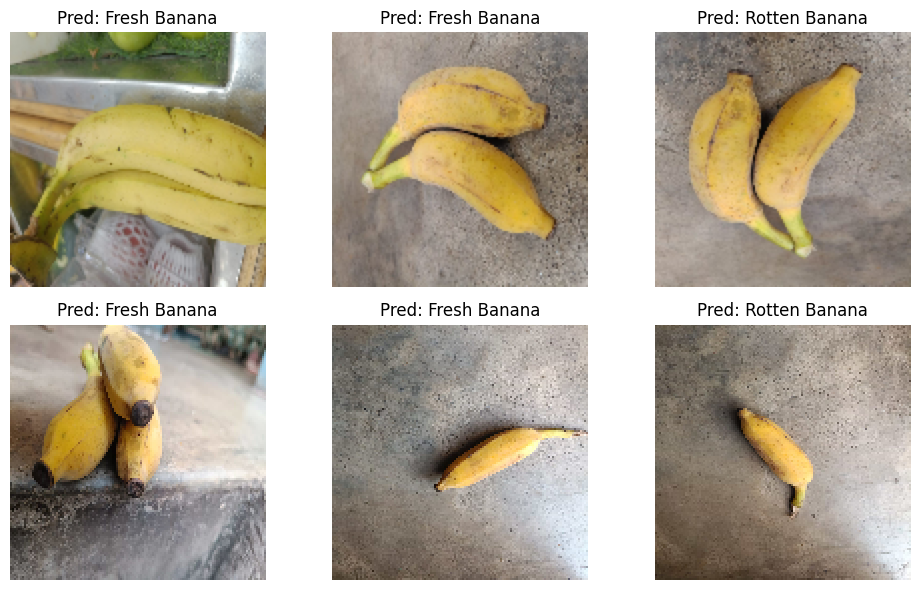

In [ ]:
import random

plt.figure(figsize=(10,6))

# ambil 6 index random dari data test
random_indices = random.sample(range(len(X_test)), 6)

for i, idx in enumerate(random_indices):
    plt.subplot(2,3,i+1)

    # ambil gambar sesuai index test
    img = data[idx]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Pred: {categories[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **15. EXPORT KE EXCEL UNTUK HASIL KLASIFIKASI**

In [ ]:
categories_excel = ["Segar", "Busuk"]

results = []

for i in range(len(y_test)):
    results.append({
        "Image": file_test[i],
        "Classification": categories_excel[y_pred[i]]
    })

df = pd.DataFrame(results)

output_path = "/content/hasil_klasifikasi_pisang.xlsx"
df.to_excel(output_path, index=False)

print("File disimpan:", output_path)

File disimpan: /content/hasil_klasifikasi_pisang.xlsx


In [ ]:
from google.colab import files
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **16. TESTING DENGAN CITRA INPUTAN**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMG-20241220-WA0038 - Copy - Copy.jpg to IMG-20241220-WA0038 - Copy - Copy.jpg


In [ ]:
categories_excel = ["Segar", "Busuk"]

for file_name in uploaded.keys():

    # Load gambar
    img = cv2.imread(file_name)
    img = cv2.resize(img, (128, 128))

    # Ekstraksi fitur (pakai fungsi yang sama)
    feat = extract_features(img)
    feat = feat.reshape(1, -1)

    # Prediksi
    pred = model.predict(feat)

    # Tampilkan hasil
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Hasil: {categories_excel[pred[0]]}")
    plt.axis("off")
    plt.show()

    print(f"{file_name} → {categories_excel[pred[0]]}")

NameError: name 'uploaded' is not defined